In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the unified dataset
df = pd.read_csv('../data/raw/ethiopia_fi_unified_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (43, 34)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [2]:
print("Record types:\n", df['record_type'].value_counts())

Record types:
 record_type
observation    30
event          10
target          3
Name: count, dtype: int64


In [3]:
observations = df[df['record_type'] == 'observation']
print(f"Observations: {len(observations)}")
print("Indicators covered:\n", observations['indicator_code'].value_counts())
print("\nDate range:", observations['observation_date'].min(), "to", observations['observation_date'].max())

Observations: 30
Indicators covered:
 indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
Name: count, dtype: int64

Date range: 2014-12-31 to 2025-12-31


In [7]:
# Show all event data
events = df[df['record_type'] == 'event']
print(events[['record_id', 'category', 'indicator', 'observation_date']].head(10))

   record_id        category                               indicator  \
33  EVT_0001  product_launch                         Telebirr Launch   
34  EVT_0002    market_entry    Safaricom Ethiopia Commercial Launch   
35  EVT_0003  product_launch                  M-Pesa Ethiopia Launch   
36  EVT_0004  infrastructure        Fayda Digital ID Program Rollout   
37  EVT_0005          policy         Foreign Exchange Liberalization   
38  EVT_0006       milestone     P2P Transaction Count Surpasses ATM   
39  EVT_0007     partnership            M-Pesa EthSwitch Integration   
40  EVT_0008  infrastructure  EthioPay Instant Payment System Launch   
41  EVT_0009          policy                 NFIS-II Strategy Launch   
42  EVT_0010         pricing       Safaricom Ethiopia Price Increase   

   observation_date  
33       2021-05-17  
34       2022-08-01  
35       2023-08-01  
36       2024-01-01  
37       2024-07-29  
38       2024-10-01  
39       2025-10-27  
40       2025-12-18  
41       

In [5]:
impact_links = df[df['record_type'] == 'impact_link']
print(f"Impact links: {len(impact_links)}")
impact_links.head()

Impact links: 0


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes


Possible digital payment codes: ['USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE']
Digital payments indicator not found. Try one of: ['USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE']


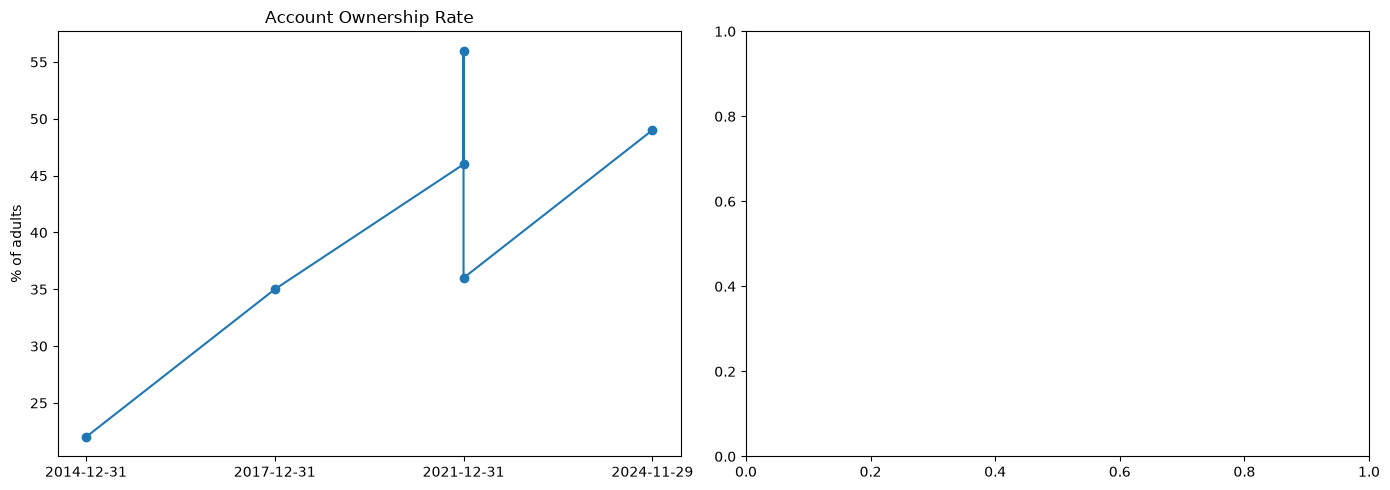

In [12]:
# Plot account ownership and digital payments over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Account ownership - use the correct code from your dataset
account = observations[observations['indicator_code'] == 'ACC_OWNERSHIP']
if len(account) > 0:
    axes[0].plot(account['observation_date'], account['value_numeric'], marker='o')
    axes[0].set_title('Account Ownership Rate')
    axes[0].set_ylabel('% of adults')
else:
    print("ACC_OWNERSHIP not found. Available codes:", observations['indicator_code'].unique())

# Digital payments - find the correct code
digital_codes = [c for c in observations['indicator_code'].unique() if 'PAY' in c or 'DIGITAL' in c or 'USG' in c]
print("Possible digital payment codes:", digital_codes)

# Pick the right one (check your data)
digital = observations[observations['indicator_code'] == 'USG_DIGITAL_PAYMENTS']  # or whatever the code is
if len(digital) > 0:
    axes[1].plot(digital['observation_date'], digital['value_numeric'], marker='o', color='green')
    axes[1].set_title('Digital Payment Adoption Rate')
    axes[1].set_ylabel('% of adults')
else:
    print("Digital payments indicator not found. Try one of:", digital_codes)

plt.tight_layout()
plt.show()

In [9]:
print("By pillar:\n", observations['pillar'].value_counts())
print("\nBy source_type:\n", observations['source_type'].value_counts())

By pillar:
 pillar
ACCESS           14
USAGE            11
GENDER            4
AFFORDABILITY     1
Name: count, dtype: int64

By source_type:
 source_type
operator      11
survey        10
research       4
regulator      3
calculated     2
Name: count, dtype: int64


In [11]:
events = df[df['record_type'] == 'event']

print("Events:")
for _, row in events.iterrows():
    print(f"{row['observation_date']} – {row['indicator']} ({row['category']})")

Events:
2021-05-17 – Telebirr Launch (product_launch)
2022-08-01 – Safaricom Ethiopia Commercial Launch (market_entry)
2023-08-01 – M-Pesa Ethiopia Launch (product_launch)
2024-01-01 – Fayda Digital ID Program Rollout (infrastructure)
2024-07-29 – Foreign Exchange Liberalization (policy)
2024-10-01 – P2P Transaction Count Surpasses ATM (milestone)
2025-10-27 – M-Pesa EthSwitch Integration (partnership)
2025-12-18 – EthioPay Instant Payment System Launch (infrastructure)
2021-09-01 – NFIS-II Strategy Launch (policy)
2025-12-15 – Safaricom Ethiopia Price Increase (pricing)
